In [6]:
# importing the dependencies
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use("default")
sns.set_context("notebook")


### Load dataset

In [7]:
df=pd.read_csv("SalaryDataset.csv")

In [8]:
df

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android
2,4.0,Unacademy,Android Developer,1000000,3,Bangalore,Full Time,Android
3,3.8,SnapBizz Cloudtech,Android Developer,300000,3,Bangalore,Full Time,Android
4,4.4,Appoids Tech Solutions,Android Developer,600000,3,Bangalore,Full Time,Android
...,...,...,...,...,...,...,...,...
22765,4.7,Expert Solutions,Web Developer,200000,1,Bangalore,Full Time,Web
22766,4.0,Nextgen Innovation Labs,Web Developer,300000,1,Bangalore,Full Time,Web
22767,4.1,Fresher,Full Stack Web Developer,192000,13,Bangalore,Full Time,Web
22768,4.1,Accenture,Full Stack Web Developer,300000,7,Bangalore,Full Time,Web


In [9]:
df.shape

(22770, 8)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22770 entries, 0 to 22769
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Rating             22770 non-null  float64
 1   Company Name       22769 non-null  object 
 2   Job Title          22770 non-null  object 
 3   Salary             22770 non-null  int64  
 4   Salaries Reported  22770 non-null  int64  
 5   Location           22770 non-null  object 
 6   Employment Status  22770 non-null  object 
 7   Job Roles          22770 non-null  object 
dtypes: float64(1), int64(2), object(5)
memory usage: 1.4+ MB


In [11]:
df.describe()

,Rating,Salary,Salaries Reported
count,22770.000000,2.277000e+04,22770.000000
mean,3.918213,6.953872e+05,1.855775
std,0.519675,8.843990e+05,6.823668
min,1.000000,2.112000e+03,1.000000
25%,3.700000,3.000000e+05,1.000000
50%,3.900000,5.000000e+05,1.000000
75%,4.200000,9.000000e+05,1.000000
max,5.000000,9.000000e+07,361.000000


In [12]:
df.describe(include='all')

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
count,22770.000000,22769,22770,2.277000e+04,22770.000000,22770,22770,22770
unique,NaN,11260,1080,NaN,NaN,10,4,11
top,NaN,Tata Consultancy Services,Software Development Engineer,NaN,NaN,Bangalore,Full Time,SDE
freq,NaN,271,2351,NaN,NaN,8264,20083,8183
mean,3.918213,NaN,NaN,6.953872e+05,1.855775,NaN,NaN,NaN
std,0.519675,NaN,NaN,8.843990e+05,6.823668,NaN,NaN,NaN
min,1.000000,NaN,NaN,2.112000e+03,1.000000,NaN,NaN,NaN
25%,3.700000,NaN,NaN,3.000000e+05,1.000000,NaN,NaN,NaN
50%,3.900000,NaN,NaN,5.000000e+05,1.000000,NaN,NaN,NaN
75%,4.200000,NaN,NaN,9.000000e+05,1.000000,NaN,NaN,NaN


In [13]:
## check missing values
df.isnull().sum()

Rating               0
Company Name         1
Job Title            0
Salary               0
Salaries Reported    0
Location             0
Employment Status    0
Job Roles            0
dtype: int64

In [16]:
df.dropna(inplace=True)

In [17]:
df.isnull().sum()

Rating               0
Company Name         0
Job Title            0
Salary               0
Salaries Reported    0
Location             0
Employment Status    0
Job Roles            0
dtype: int64

In [18]:
df.shape

(22769, 8)

## Remove duplicates

In [21]:
df=df.drop_duplicates()
df

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android
2,4.0,Unacademy,Android Developer,1000000,3,Bangalore,Full Time,Android
3,3.8,SnapBizz Cloudtech,Android Developer,300000,3,Bangalore,Full Time,Android
4,4.4,Appoids Tech Solutions,Android Developer,600000,3,Bangalore,Full Time,Android
...,...,...,...,...,...,...,...,...
22765,4.7,Expert Solutions,Web Developer,200000,1,Bangalore,Full Time,Web
22766,4.0,Nextgen Innovation Labs,Web Developer,300000,1,Bangalore,Full Time,Web
22767,4.1,Fresher,Full Stack Web Developer,192000,13,Bangalore,Full Time,Web
22768,4.1,Accenture,Full Stack Web Developer,300000,7,Bangalore,Full Time,Web


## Outliers detection and removal

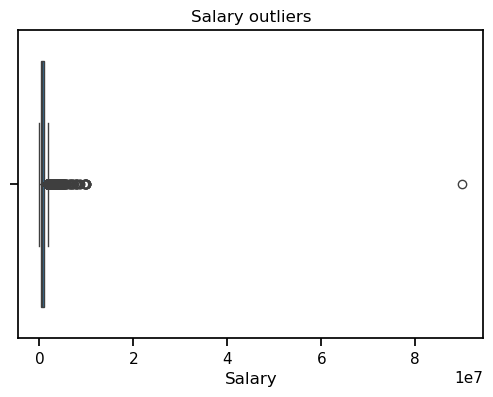

In [23]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Salary'])
plt.title("Salary outliers")
plt.savefig("SalaryOutliers.png",bbox_inches='tight')
plt.show()

### IQR (Interquartile Range) Method

In [24]:
Q1=df.Salary.quantile(0.25)
Q3=df.Salary.quantile(0.75)
IQR=Q3-Q1

In [25]:
lower_limit=Q1-1.5 * IQR
upper_limit=Q3+1.5 * IQR

In [26]:
df=df[(df.Salary>=lower_limit) & (df.Salary<=upper_limit)]

In [27]:
df

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android
2,4.0,Unacademy,Android Developer,1000000,3,Bangalore,Full Time,Android
3,3.8,SnapBizz Cloudtech,Android Developer,300000,3,Bangalore,Full Time,Android
4,4.4,Appoids Tech Solutions,Android Developer,600000,3,Bangalore,Full Time,Android
...,...,...,...,...,...,...,...,...
22765,4.7,Expert Solutions,Web Developer,200000,1,Bangalore,Full Time,Web
22766,4.0,Nextgen Innovation Labs,Web Developer,300000,1,Bangalore,Full Time,Web
22767,4.1,Fresher,Full Stack Web Developer,192000,13,Bangalore,Full Time,Web
22768,4.1,Accenture,Full Stack Web Developer,300000,7,Bangalore,Full Time,Web


## Univariate Analysis

#### Salary distribution

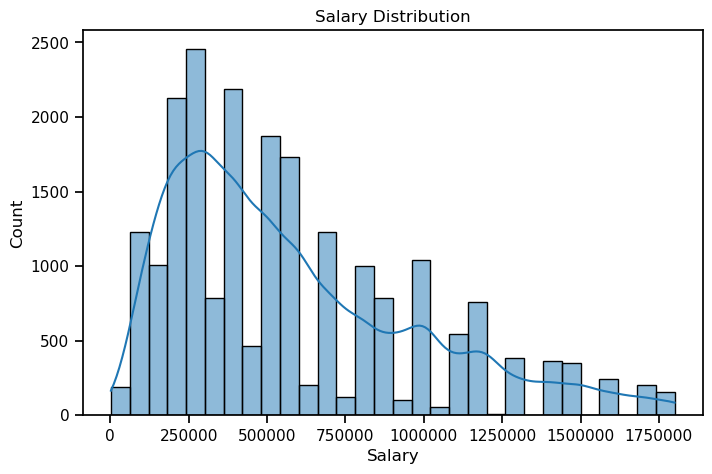

In [30]:
plt.figure(figsize=(8,5))
sns.histplot(df.Salary,bins=30,kde=True)

## make the salary in a readable format
plt.ticklabel_format(style='plain', axis='x')

plt.title("Salary Distribution")
plt.savefig("SalaryDistribution.png",bbox_inches='tight')
plt.show()

## 1.What does salary distribution look like?

## 2.Which job roles have the highest average salary?

In [32]:
df.head(2)

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android


In [33]:
df['Job Roles'].value_counts()

Job Roles
SDE         7572
Android     2856
Frontend    2088
Java        1805
Testing     1723
IOS         1559
Backend     1092
Web          990
Python       937
Database     768
Mobile       223
Name: count, dtype: int64

In [34]:
df['Job Roles'].unique()

array(['Android', 'Backend', 'Database', 'Frontend', 'IOS', 'Java',
       'Mobile', 'SDE', 'Python', 'Web', 'Testing'], dtype=object)

In [35]:
df['Job Roles'].nunique()

11

In [41]:
job_salary=df.groupby('Job Roles')['Salary'].mean().sort_values(ascending=False).head(10)
job_salary

Job Roles
Database    745670.833333
SDE         693039.416799
Mobile      648251.121076
IOS         617741.013470
Backend     574203.926740
Frontend    532927.754789
Android     501886.106443
Java        493755.957895
Testing     474144.130006
Python      460101.327641
Name: Salary, dtype: float64

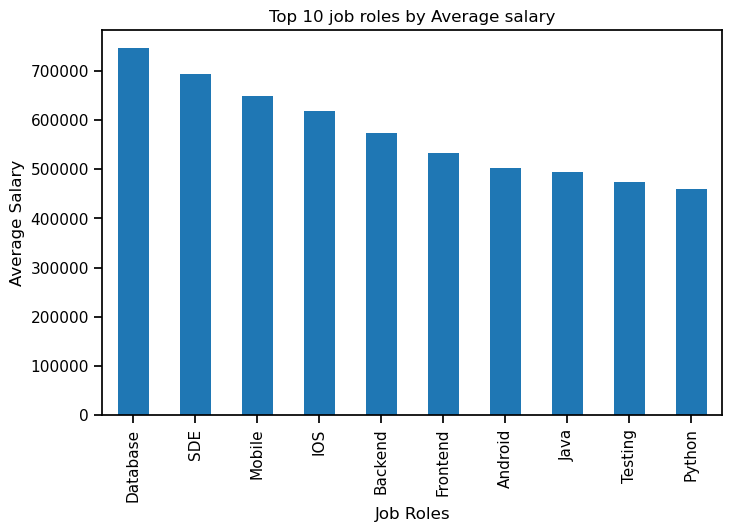

In [43]:
plt.figure(figsize=(8,5))
job_salary.plot(kind='bar')
plt.title("Top 10 job roles by Average salary")
plt.ylabel("Average Salary")
plt.savefig("Top10JobRolesByAvgSalary.png",bbox_inches='tight')
plt.show()

### Check for outliers again

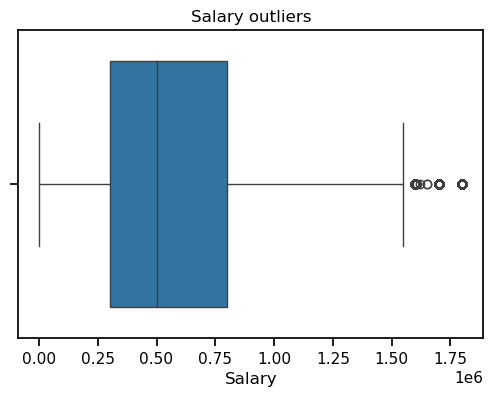

In [44]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Salary'])
plt.title("Salary outliers")
plt.savefig("SalaryOutliers2.png",bbox_inches='tight')
plt.show()

In [45]:
Q1=df.Salary.quantile(0.25)
Q3=df.Salary.quantile(0.75)
IQR=Q3-Q1

In [46]:
lower_limit=Q1-1.5 * IQR
upper_limit=Q3+1.5 * IQR

In [47]:
df=df[(df.Salary>=lower_limit) & (df.Salary<=upper_limit)]

In [48]:
df

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android
2,4.0,Unacademy,Android Developer,1000000,3,Bangalore,Full Time,Android
3,3.8,SnapBizz Cloudtech,Android Developer,300000,3,Bangalore,Full Time,Android
4,4.4,Appoids Tech Solutions,Android Developer,600000,3,Bangalore,Full Time,Android
...,...,...,...,...,...,...,...,...
22765,4.7,Expert Solutions,Web Developer,200000,1,Bangalore,Full Time,Web
22766,4.0,Nextgen Innovation Labs,Web Developer,300000,1,Bangalore,Full Time,Web
22767,4.1,Fresher,Full Stack Web Developer,192000,13,Bangalore,Full Time,Web
22768,4.1,Accenture,Full Stack Web Developer,300000,7,Bangalore,Full Time,Web


### No outliers

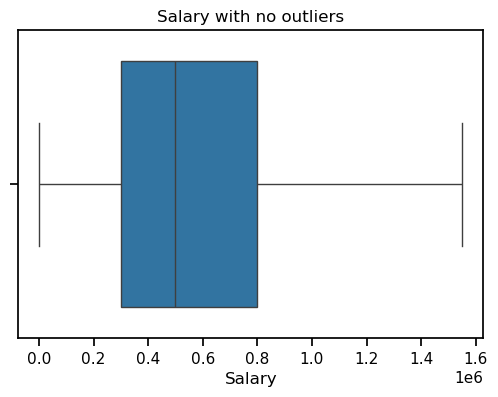

In [49]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Salary'])
plt.title("Salary with no outliers")
plt.savefig("SalaryWithNoOutliers.png",bbox_inches='tight')
plt.show()

### Checking salary distribution after no outliers

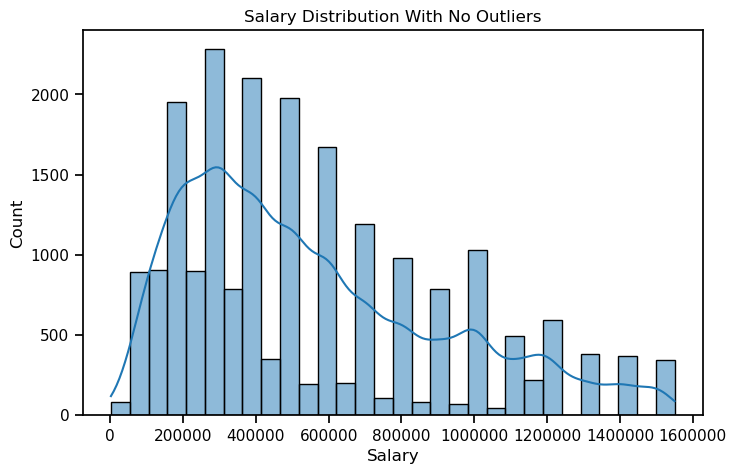

In [51]:
plt.figure(figsize=(8,5))
sns.histplot(df.Salary,bins=30,kde=True)

## make the salary in a readable format
plt.ticklabel_format(style='plain', axis='x')

plt.title("Salary Distribution With No Outliers")
plt.savefig("SalaryDistributionWithNoOutliers.png",bbox_inches='tight')
plt.show()

### There are changes in  the dataset without  outliers are there currently

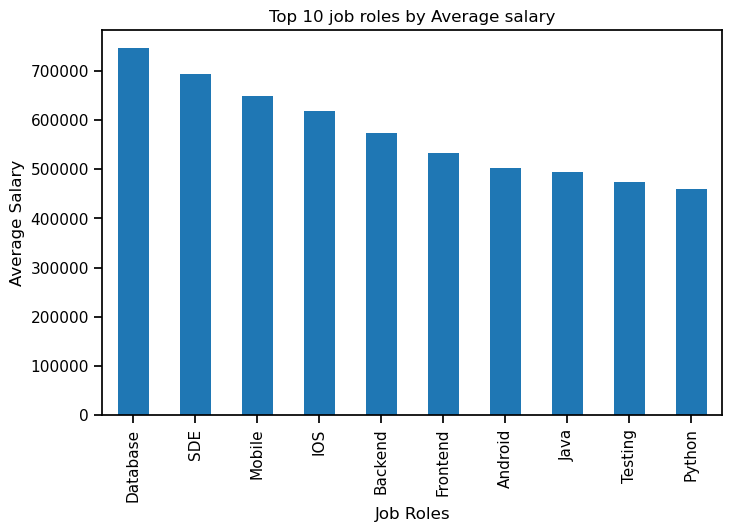

In [53]:
plt.figure(figsize=(8,5))
job_salary.plot(kind='bar')
plt.title("Top 10 job roles by Average salary")
plt.ylabel("Average Salary")
plt.savefig("Top10JobRolesByAvgSalary2.png",bbox_inches='tight')
plt.show()

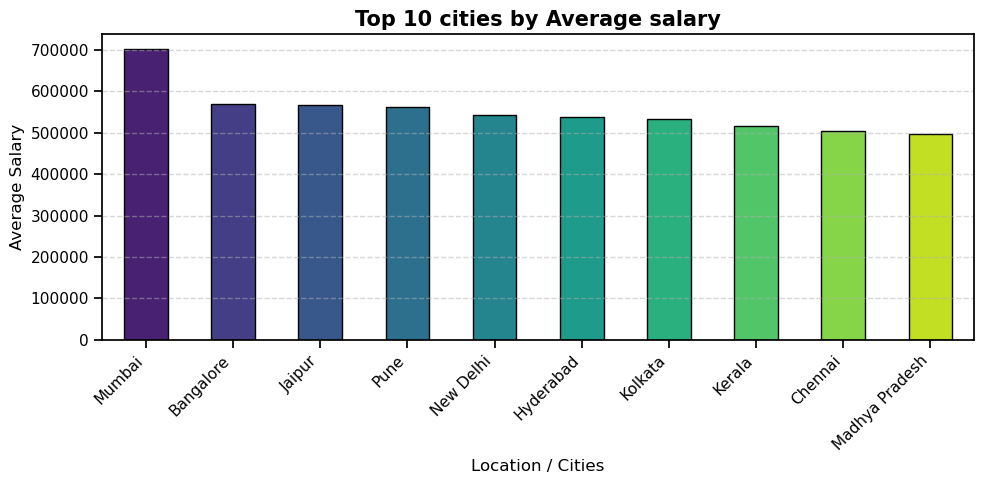

In [67]:
plt.figure(figsize=(10,5))
colors=sns.color_palette("viridis",len(city_salary))
city_salary.plot(kind='bar',color=colors,edgecolor="black")
plt.title("Top 10 cities by Average salary",fontsize=15,fontweight="bold")
plt.ylabel("Average Salary")
plt.xlabel("Location / Cities")
plt.xticks(rotation=45,ha="right")
plt.grid(axis='y',linestyle='--',alpha=0.5)
plt.tight_layout()
plt.savefig("Top10CitiesByAvgSalary.png",bbox_inches='tight')
plt.show()

## 3.Which cities offer the highest average salaries?

In [55]:
df.head(2)

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android


In [59]:
city_salary=df.groupby("Location")['Salary'].mean().sort_values(ascending=False)
city_salary

Location
Mumbai            702195.874214
Bangalore         568140.303079
Jaipur            566153.846154
Pune              562387.138833
New Delhi         542717.057751
Hyderabad         538809.567450
Kolkata           532604.938272
Kerala            514965.735849
Chennai           505102.446337
Madhya Pradesh    497530.378378
Name: Salary, dtype: float64

## 4.Name those 5 companies located in New Delhi with rating of '5' , offering highest and lowest salaries

In [68]:
df.head(2)

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android


In [72]:
new_delhi_r5=df[(df.Location=='New Delhi' ) * (df.Rating==5)].sort_values(by='Salary',ascending=False)
new_delhi_r5

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
6750,5.0,Hapramp,Front End Developer,1500000,1,New Delhi,Full Time,Frontend
1888,5.0,Trillbit,Android Developer,1500000,1,New Delhi,Full Time,Android
17488,5.0,The Art of Mike Mignola,Software Development Engineer,1500000,1,New Delhi,Full Time,SDE
8284,5.0,Silicon Valley Recycling,Senior IOS Developer,1400000,1,New Delhi,Full Time,IOS
17351,5.0,Parth Universal,Software Development Engineer,1300000,1,New Delhi,Full Time,SDE
...,...,...,...,...,...,...,...,...
1723,5.0,Neo Fitnes,Android Developer,100000,1,New Delhi,Full Time,Android
1969,5.0,WorkingNation,Android Developer - Intern,84000,1,New Delhi,Intern,Android
2334,5.0,Hopin (India),Android Developer - Intern,60000,1,New Delhi,Intern,Android
17524,5.0,Star Catalysts,Software Development Engineer - Intern,60000,1,New Delhi,Intern,SDE


In [77]:
## Top 5
list(new_delhi_r5['Company Name'].head())

['Hapramp',
 'Trillbit',
 'The Art of Mike Mignola',
 'Silicon Valley Recycling',
 'Parth Universal']

In [78]:
##  Bottom 5
list(new_delhi_r5['Company Name'].tail())

['Neo Fitnes', 'WorkingNation', 'Hopin (India)', 'Star Catalysts', 'Atom 8']

 ## 5.Which job title has the highest number of salary reported

In [79]:
df.head(2)

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android


In [80]:
df['Job Title'].value_counts()

Job Title
Software Development Engineer          2136
Android Developer                      1983
Software Development Engineer (SDE)    1477
Front End Developer                    1360
Test Engineer                          1290
                                       ... 
Software Engineer III - IOS               1
Senior IOS Developer and Tech Lead        1
Associate Developer - IOS                 1
Senior Analyst (IOS/IPhone)               1
Associate Web Developer                   1
Name: count, Length: 981, dtype: int64

In [83]:
df.groupby('Job Title')['Salaries Reported'].count().sort_values(ascending=False)

Job Title
Software Development Engineer                          2136
Android Developer                                      1983
Software Development Engineer (SDE)                    1477
Front End Developer                                    1360
Test Engineer                                          1290
                                                       ... 
Lead Software Development Engineer In Test Engineer       1
Lead Software Test Engineer                               1
Lead, IOS Team                                            1
Level II Mobile Technician                                1
Xamarin Mobile Developer                                  1
Name: Salaries Reported, Length: 981, dtype: int64

## 6.Which 10 companies provide the highest average salary, when at leasts 20 employees have reported their salaries?

In [85]:
df.head(2)

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android


In [91]:
filtered_df=df[df['Salaries Reported']>=20]
filtered_df

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
8790,3.9,Tata Consultancy Services,Java Developer,200000,30,Chennai,Full Time,Java
8977,3.8,Cognizant Technology Solutions,Senior Java Developer,200000,35,Chennai,Full Time,Java
8978,3.9,Tata Consultancy Services,Senior Java Developer,300000,30,Chennai,Full Time,Java
8979,3.9,Tata Consultancy Services,Junior Java Developer,200000,30,Chennai,Full Time,Java
9688,3.9,Tata Consultancy Services,Java Developer,200000,43,Hyderabad,Full Time,Java
...,...,...,...,...,...,...,...,...
21762,3.8,CGI,Senior Test Engineer,400000,21,Bangalore,Full Time,Testing
21763,4.1,IBM,Test Automation Engineer,400000,21,Bangalore,Full Time,Testing
21764,3.7,SLK Group,Software Test Engineer,300000,20,Bangalore,Full Time,SDE
21765,4.3,Cisco Systems,Software Test Engineer,700000,20,Bangalore,Full Time,SDE


In [93]:
filtered_df.groupby('Company Name')['Salary'].mean().sort_values(ascending=False).head(10)

Company Name
Expedia Group     1.350000e+06
Nokia             1.200000e+06
Amadeus           1.200000e+06
Ola               1.000000e+06
Alcatel-Lucent    1.000000e+06
Lumen             9.000000e+05
Kony              9.000000e+05
Microsoft         7.845714e+05
Cisco Systems     7.000000e+05
McAfee            6.500000e+05
Name: Salary, dtype: float64

## 7.Is there a relationship between company rationg and salary?

In [95]:
df.head(2)

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android


In [97]:
df.corr(numeric_only=True)


,Rating,Salary,Salaries Reported
Rating,1.000000,0.024760,-0.013515
Salary,0.024760,1.000000,-0.021662
Salaries Reported,-0.013515,-0.021662,1.000000


In [98]:
df.Rating.corr(df.Salary)

np.float64(0.024759533647245226)

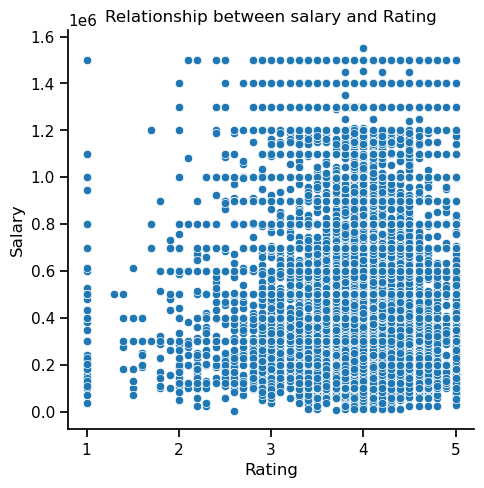

In [101]:
sns.relplot(x='Rating',y='Salary',data=df)
plt.title("Relationship between salary and Rating")
plt.savefig("RelationshipBetweenSalaryAndRating.png",bbox_inches='tight')
plt.show()

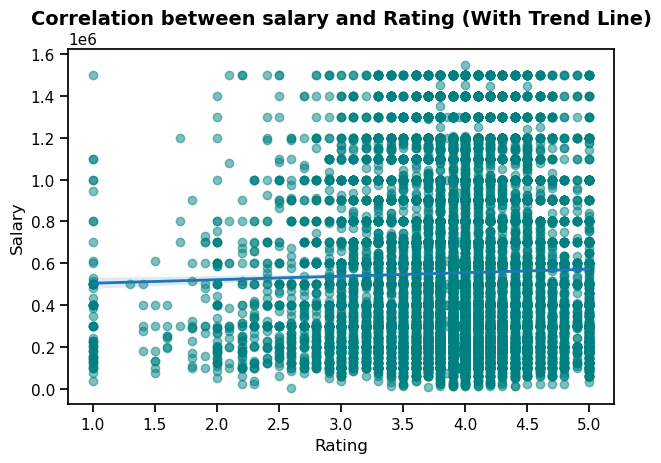

In [103]:
sns.regplot(x='Rating',y='Salary',data=df,scatter_kws={"alpha":0.5,"color":"teal"},line_kws={"linewidth":2})
plt.title("Correlation between salary and Rating (With Trend Line)" ,fontsize=14,fontweight='bold')
plt.ylabel("Company Rating")
plt.ylabel("Salary")
plt.tight_layout()
plt.savefig("CorrelationBetweenSalaryAndRating.png",bbox_inches='tight')
plt.show()

## 8.Does employment status affect salary?

In [105]:
df.head(2)

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android


In [106]:
df["Employment Status"].unique()

array(['Full Time', 'Intern', 'Contractor', 'Trainee'], dtype=object)

In [107]:
df["Employment Status"].value_counts()

Employment Status
Full Time     18378
Intern         2089
Contractor      513
Trainee          33
Name: count, dtype: int64

In [108]:
df.groupby('Employment Status')['Salary'].describe()

,count,mean,std,min,25%,50%,75%,max
Employment Status,,,,,,,,
Contractor,513.0,501507.586745,315663.813209,12000.0,300000.0,400000.0,600000.0,1500000.0
Full Time,18378.0,579272.415279,358047.046792,8448.0,300000.0,500000.0,800000.0,1550000.0
Intern,2089.0,338353.991383,264180.887035,2112.0,144000.0,264000.0,456000.0,1500000.0
Trainee,33.0,324303.030303,241096.516572,96000.0,144000.0,240000.0,400000.0,1100000.0


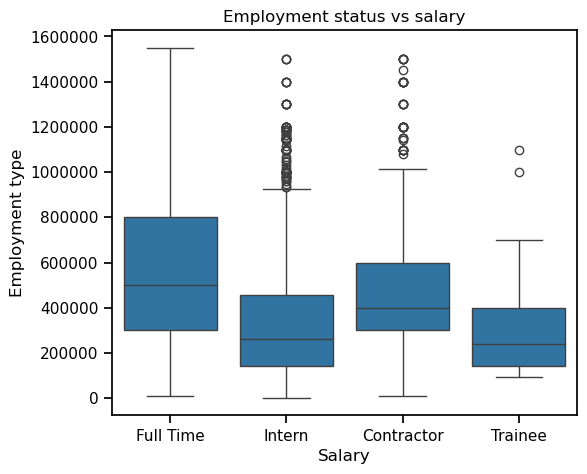

In [112]:
plt.figure(figsize=(6,5))
sns.boxplot(x="Employment Status",y="Salary",data=df)
plt.ticklabel_format(style="plain",axis='y')
plt.title("Employment status vs salary",fontsize=12)
plt.ylabel("Employment type")
plt.xlabel("Salary")
plt.savefig("EmploymentStatusVsSalary.png",bbox_inches='tight')
plt.show()

## 9.Which job roles are most common?

In [113]:
df.head(2)

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android


In [114]:
df['Job Roles'].value_counts()

Job Roles
SDE         7244
Android     2812
Frontend    2034
Java        1778
Testing     1710
IOS         1524
Backend     1049
Web          988
Python       929
Database     734
Mobile       211
Name: count, dtype: int64

In [116]:
top_roles=df['Job Roles'].value_counts().head(10)

In [117]:
top_roles

Job Roles
SDE         7244
Android     2812
Frontend    2034
Java        1778
Testing     1710
IOS         1524
Backend     1049
Web          988
Python       929
Database     734
Name: count, dtype: int64

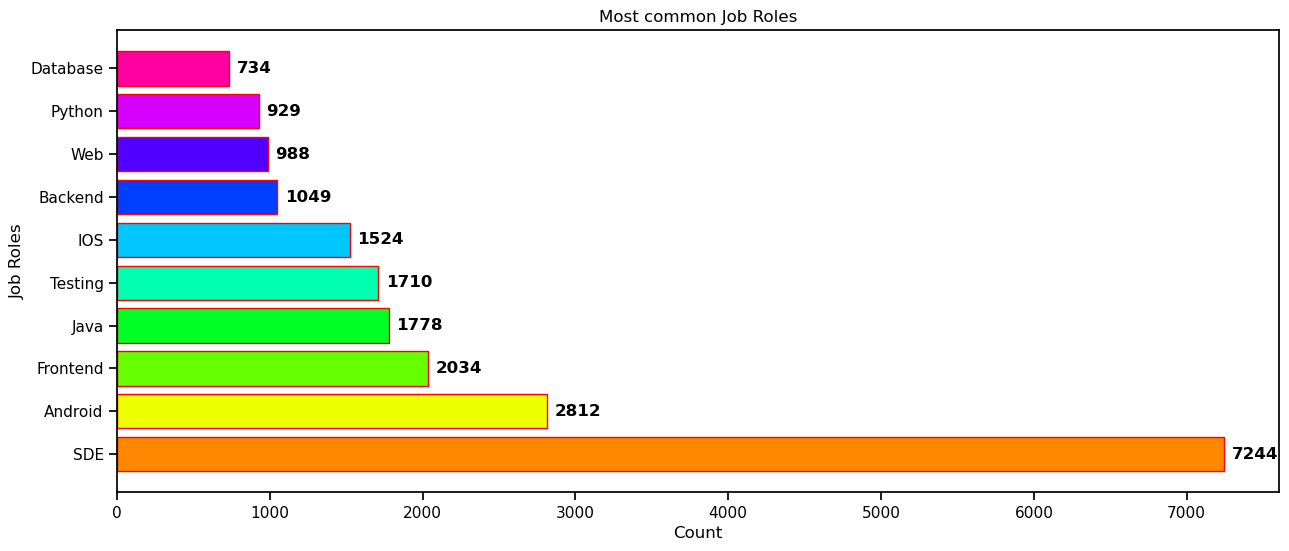

In [126]:
plt.figure(figsize=(15,6))
# use gradient colors
colors=sns.color_palette("hsv",len(top_roles))
#horizontal bar chart
plt.barh(top_roles.index,top_roles.values,color=colors,edgecolor='red')
plt.title("Most common Job Roles")
plt.ylabel("Job Roles")
plt.xlabel("Count")
# Add value label on bars
for i , v in enumerate(top_roles.values):
    plt.text(v+50,i,str(v),va='center',fontweight='bold')

plt.savefig("MostCommonJobRoles.png",bbox_inches='tight')
plt.show()

## 9.How does average salary change as company rating increase?

In [127]:
df.head(2)

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android


In [132]:
rating_salary=df.groupby("Rating")['Salary'].mean().reset_index()
rating_salary.head()

,Rating,Salary
0,1.0,399971.500000
1,1.3,500000.000000
2,1.4,331200.000000
3,1.5,241000.000000
4,1.6,262285.714286


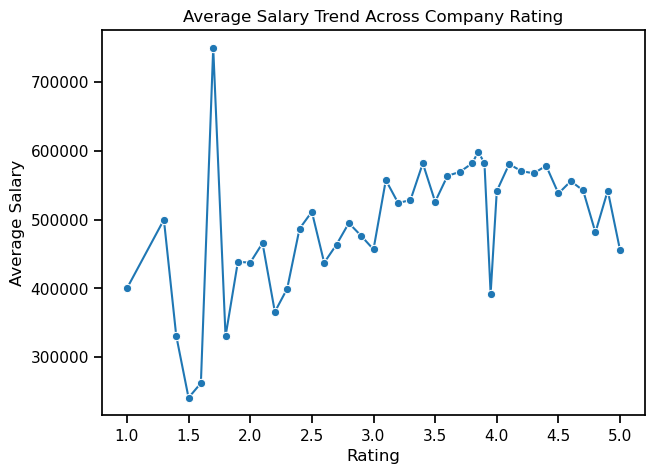

In [135]:
plt.figure(figsize=(7,5))

sns.lineplot(x="Rating",y="Salary",data=rating_salary,marker='o')
plt.title("Average Salary Trend Across Company Rating")
plt.xlabel("Rating")
plt.ylabel("Average Salary")
plt.savefig("AverageSalaryTrendAcrossCompanyRating.png",bbox_inches='tight')
plt.show()

## Mini Dashboard

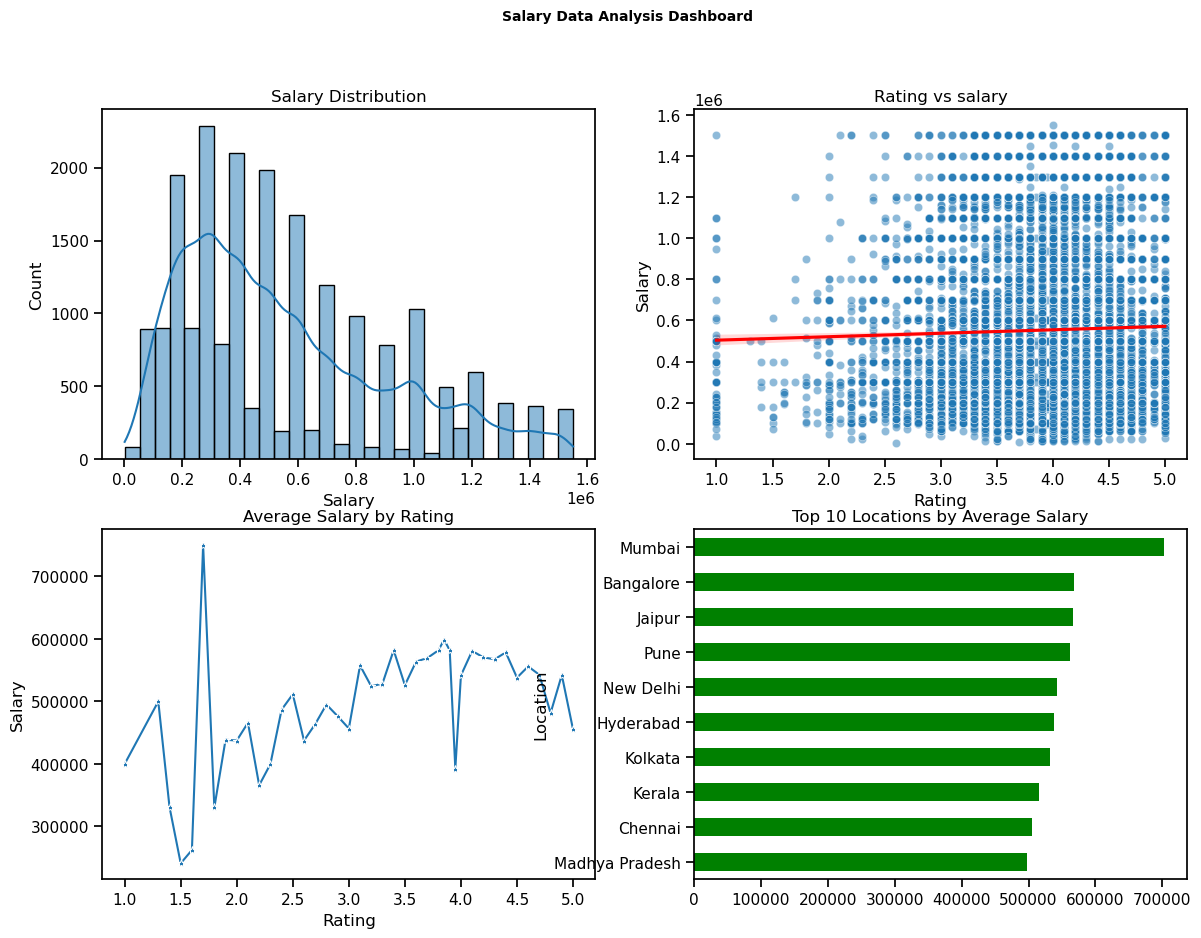

In [139]:
# prepare data
rating_salary=df.groupby("Rating")["Salary"].mean().reset_index()
top_locations=df.groupby("Location")['Salary'].mean().sort_values(ascending=False)
# create dashboard layout
plt.figure(figsize=(14,10))
#1. salary Distribution
plt.subplot(2,2,1)
sns.histplot(df["Salary"],bins=30,kde=True)
plt.title("Salary Distribution")

#2. Rating vs salary
plt.subplot(2,2,2)
sns.scatterplot(x="Rating",y="Salary",data=df,alpha=0.5)
sns.regplot(x="Rating",y="Salary",data=df,scatter=False,color='red')
plt.title("Rating vs salary")

#3.Average salary by rating
plt.subplot(2,2,3)
sns.lineplot(x="Rating",y="Salary",data=rating_salary,marker='*')
plt.title("Average Salary by Rating")

#4.Top location
plt.subplot(2,2,4)
top_locations.sort_values().plot(kind='barh',color='g')
plt.title("Top 10 Locations by Average Salary")

plt.suptitle("Salary Data Analysis Dashboard", fontsize=10,fontweight='bold')



plt.savefig("Dashboard.png",bbox_inches='tight')
plt.show()

In [ ]:
## Top 5 companies offering the highest average salary?

In [ ]:
## How do salaries vary across location?